# EDA and Submission for Playground Series - Season 6 Episode 5: Predicting F1 Pit Stops

## EDA

Load the training data and check for missing values.

In [2]:
import pandas as pd

training_data = '/kaggle/input/competitions/playground-series-s6e5/train.csv'
df = pd.read_csv(training_data)
print(f'Missing Values:\n{df.isnull().sum()}')

Missing Values:
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64


Great, there's no missing values! Now let's check the class balance of our training dataset.

<Axes: xlabel='PitNextLap'>

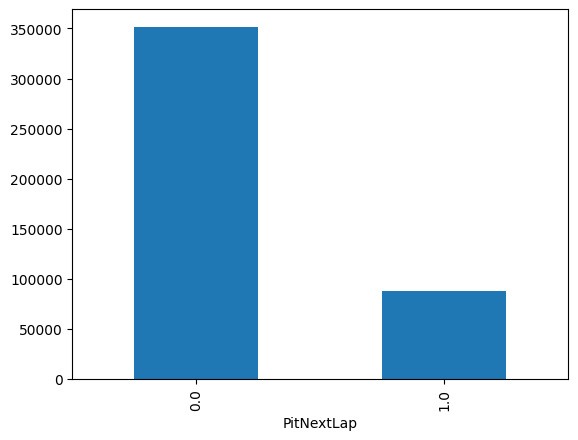

In [3]:
counts = df['PitNextLap'].value_counts()
counts.plot(kind='bar')

There's quite a large imbalance between classes. We could split our data into training
and validation sets, then oversample the minority class. That's a large
discrepancy though and I worry about the quality of the oversampled data, even when using something like SMOTE. Based on other EDA in the competition discussion, there are a lot of inconsistencies in the data, both in the synthetic competition data, as well as in the original.
Thankfully we can choose classifiers that can handle class imbalance directly, by using weights proportional to the size of the class.

Now let's remove the target labels and ids and classify the features based on the data preprocessing steps that we will apply to them (target encoding and standard scaling).

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer

X_full = df.drop(columns=['id', 'PitNextLap'])
te_cols = ['Driver', 'Compound', 'Race', 'Year']
sc_cols = X_full.drop(columns=te_cols).columns
y = df['PitNextLap'].to_numpy()

preprocessor = ColumnTransformer(
    transformers=[
        ('te', TargetEncoder(categories='auto', target_type='binary', smooth='auto', cv=5, random_state=42), te_cols),
        ('sc', StandardScaler(), sc_cols)
    ]
)

pipe = Pipeline([('preprocessor', preprocessor)])

x = X_full

## Training

We will train three different gradient boosting classifier algorithms on our data. These classifiers are LightGBM, CatBoost, and HistGradientBoost. In addition, we will use a custom designed and trained neural network model using PyTorch. This NN model uses the BCELoss function, Adam optimizer, and a series of linear layers with ReLU activation functions. The model is wrapped in a scikit-learn classifier class so that we can use it in the rest of our pipelines.

The following parameters were chosen through hperparameter tuning using Optuna and MLFlow with 5-fold cross validation and roc_auc scoring to choose the best model.
The tuning process is left out for brevity and runtime but the code can be found on my github for this project.

In [5]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(class_weight="balanced", n_estimators=5700, 
                    learning_rate=0.05908896361240603, max_depth=8, reg_lambda=5.486640904729752,
                    max_bins=168, reg_alpha=19.215331516148023, min_data_in_leaf=19,
                    boosting_type='gbdt', objective='binary', 
                    random_state=1, verbose=-1)

In [6]:
from catboost import CatBoostClassifier

params = {'iterations': 9200,
          'depth': 8,
          'learning_rate': 0.020119006272409548,
          'verbose': False,
          'reg_lambda': 16.53779318936456,
          'bagging_temperature': 0.20249506790297409,
          'auto_class_weights': 'Balanced',
          'loss_function': 'Logloss',
          'random_state': 1}
                        
from sklearn.base import clone

class CustomCatBoostClassifier(CatBoostClassifier):
    def __sklearn_clone__(self):
        return CustomCatBoostClassifier(**self.get_params())
    
cb = CustomCatBoostClassifier(**params)

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(class_weight='balanced', max_iter=8900, 
                                    learning_rate=0.18850907216092966, max_depth=9, l2_regularization=58.25398742216435,
                                    loss='log_loss', max_bins=205, random_state=1)

In [9]:
from pytorch_nn_w_sklearn_wrapper import MyNNClassifier
import torch

params = {
    "epochs": 50,
    "learning_rate": 0.0041938691081848545,
    "weight_decay": 1.0937543559179115e-06,
    "width": 30,
    "depth": 1,
    "device": 'cuda' if torch.cuda.is_available() else 'cpu',
    "in_features": x.shape[1],
}

mynn = MyNNClassifier(**params)

## Ensembling

Now let's ensemble the four models using a stacking classifier with a logistic regression meta estimator.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

p1 = Pipeline(steps=[('preprocessor', pipe), ('model', hgb)])
p2 = Pipeline(steps=[('preprocessor', pipe), ('model', lgbm)])
p3 = Pipeline(steps=[('preprocessor', pipe), ('model', cb)])
p4 = Pipeline(steps=[('preprocessor', pipe), ('model', mynn)])

base_models = [('hgb', p1), ('lgbm', p2), ('cb', p3), ('nn', p4)]

meta_model = LogisticRegression(max_iter=1000, solver="lbfgs", class_weight="balanced", random_state=1)

stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)
stacking_clf.fit(x, y)

## Testing and Submission

Now we load the test data and send it through the stacking classifier pipeline to make our predictions and write the submission file.

In [ ]:
import os

testing_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')
preds_stacking = stacking_clf.predict_proba(testing_data)[:, 1]

submission_stacking = pd.DataFrame({
    "id": testing_data["id"],
    "PitNextLap": preds_stacking
})

out_dir = '/kaggle/working/'
submission_stacking.to_csv(os.path.join(out_dir, 'submission.csv'), index=False)

## Further Experiments
This fairly basic workflow produced a decent public score (0.94896). Longer, more expansive hyperparameter tuning could
be done, as well as feature engineering. As mentioned in the competition, the original data contains a "NormalizedTyreLife" feature that makes prediction easy. I attempted training models with this new feature calculated from the competition data, but the results were essentially the same. This work can be found in some of the other files for this project on my github. 

There are also quite a few low correlating features that could possibly be combined in ways to both
reduce the number of features as well as produce a better model. Training a wider variety of models to ensemble and performing more advanced stacking of them could also possibly improve the score. 